## Preprocess the data for 2D barotropic simulations using 3D interpolated data from GLORYS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import xarray as xr
from pathlib import Path
import importlib

sys.path.append(os.path.abspath('../scripts'))
import ocean_analysis as oa 
importlib.reload(oa)


<module 'ocean_analysis' from 'c:\\Users\\Jelle Gortemaker\\Documents\\Thesis\\OGCM\\scripts\\ocean_analysis.py'>

MLD statistics [m]
Mean:   11.95
Median: 11.90


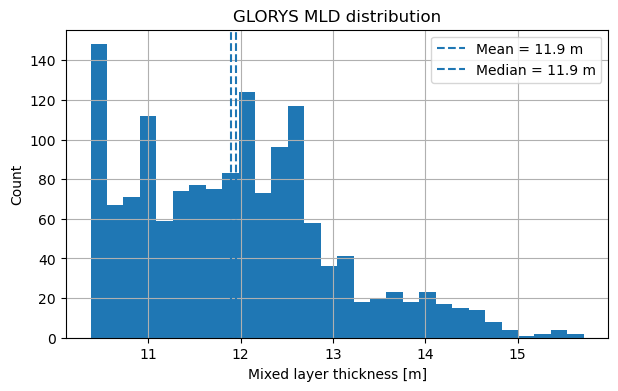

In [2]:
GLORYS_file = "../data/input/GPGP_jun2020_3D_28.50_31.50_153.56_150.24.nc"

case_name = "run_jun1"

MITgcm_interp_file = f"../../z.flow_postprocessing/data/input/{case_name}.nc"
output_file = f"MITgcm_spinup_256x256_{case_name}_2D"
delR = [12.0]



ds = xr.open_dataset(GLORYS_file)
mld = ds["mlotst"]

for tdim in ["time", "time_counter", "t"]:
    if tdim in mld.dims:
        mld = mld.mean(dim=tdim)
        break

values = mld.values
values = values[np.isfinite(values)]

print("MLD statistics [m]")
print(f"Mean:   {np.mean(values):.2f}")
print(f"Median: {np.median(values):.2f}")

plt.figure(figsize=(7, 4))
plt.hist(values, bins=30)
plt.axvline(np.mean(values), linestyle="--", label=f"Mean = {np.mean(values):.1f} m")
plt.axvline(np.median(values), linestyle="--", label=f"Median = {np.median(values):.1f} m")
plt.xlabel("Mixed layer thickness [m]")
plt.ylabel("Count")
plt.title("GLORYS MLD distribution")
plt.legend()
plt.grid(True)
plt.show()

In [3]:
oa.spinup_to_baro1_bin(
    input_nc=MITgcm_interp_file,
    output_file=f"../data/processed/{output_file}.nc",
    time_days=0,
    z_index=0,
)

Saved u velocity to: ..\data\processed\MITgcm_spinup_256x256_run_jun1_2D_uvel.bin
Saved v velocity to: ..\data\processed\MITgcm_spinup_256x256_run_jun1_2D_vvel.bin
u shape written: (1, 512, 512)
v shape written: (1, 512, 512)
Selected time dimension: T
Selected time index    : 0
Selected model time    : 712800.0 s = 8.2500 days
Selected vertical index: 0
Use readBinaryPrec = 32 in MITgcm.


{'u_bin': WindowsPath('../data/processed/MITgcm_spinup_256x256_run_jun1_2D_uvel.bin'),
 'v_bin': WindowsPath('../data/processed/MITgcm_spinup_256x256_run_jun1_2D_vvel.bin'),
 'u_shape': (1, 512, 512),
 'v_shape': (1, 512, 512),
 'time_dim': 'T',
 'time_index': 0,
 'time_seconds': 712800.0,
 'z_index': 0}

In [4]:
# oa.slice_vertical_layers_delR(
#     input_nc=MITgcm_interp_file,
#     output_nc=output_file,
#     delR=delR,
#     depth_dim="z",
#     variables=["u_mit", "v_mit"],
#     time_index=0,
#     dtype=">f4",
#     Nx=512,
#     Ny=512,
# )